<h2><b>Heart Disease Prediction using Classification Models</h2>

<b>Importing Libraries

In [1]:
import pandas as pd
import numpy as np

<b>Reading Data from the CSV FILE

In [2]:
heart=pd.read_csv('heart.csv')

In [3]:
heart.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
heart.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


<b>Dataset Information

In [5]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [6]:
heart.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [7]:
heart['trestbps']=heart['trestbps'].fillna(heart['trestbps'].mean(),inplace=True)
heart['chol'].fillna(heart['chol'].mean(),inplace=True)
heart['fbs'].fillna(heart['fbs'].mode()[0],inplace=True)
heart['restecg'].fillna(heart['restecg'].mode()[0],inplace=True)
heart['thalch'].fillna(heart['thalch'].mode()[0],inplace=True)
heart['exang'].fillna(heart['exang'].mode()[0],inplace=True)
heart['oldpeak'].fillna(heart['oldpeak'].mean(),inplace=True)
heart['slope'].fillna(heart['slope'].mode()[0],inplace=True)
heart['thal'].fillna(heart['thal'].mode()[0],inplace=True)
heart['ca'].fillna(heart['ca'].mode()[0],inplace=True)

C:\Users\kamil\AppData\Local\Temp\ipykernel_12864\611193458.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart['trestbps']=heart['trestbps'].fillna(heart['trestbps'].mean(),inplace=True)
C:\Users\kamil\AppData\Local\Temp\ipykernel_12864\611193458.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

In [8]:
heart.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps    920
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
num           0
dtype: int64

In [9]:
 heart.duplicated().any()

False

In [10]:
cate_val=[]
cont_val=[]
for column in heart.columns:
    if heart[column].nunique()<=10:
        cate_val.append(column)
    else:
        cont_val.append(column)

In [11]:
cate_val

['sex',
 'dataset',
 'cp',
 'trestbps',
 'fbs',
 'restecg',
 'exang',
 'slope',
 'ca',
 'thal',
 'num']

In [12]:
cont_val

['id', 'age', 'chol', 'thalch', 'oldpeak']

In [13]:
cate_val.remove('num')

In [14]:
heart=pd.get_dummies(heart,columns=cate_val,drop_first=True)

In [15]:
i=0
for val in heart['num']:
    if val >0:
       heart.loc[i,'num']=1
    i+=1

In [16]:
heart.shape

(920, 24)

In [17]:
heart.head()

,id,age,chol,thalch,oldpeak,num,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,...,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
0,1,63,233.0,150.0,2.3,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,67,286.0,108.0,1.5,1,True,False,False,False,...,False,False,True,True,False,False,False,True,True,False
2,3,67,229.0,129.0,2.6,1,True,False,False,False,...,False,False,True,True,False,False,True,False,False,True
3,4,37,250.0,187.0,3.5,0,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,5,41,204.0,172.0,1.4,0,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [18]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
heart[cont_val]=st.fit_transform(heart[cont_val])

In [19]:
heart.head()

,id,age,chol,thalch,oldpeak,num,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,...,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
0,-1.730169,1.007386,0.311021,0.462879,1.349421,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-1.726404,1.432034,0.797713,-1.197349,0.589832,1,True,False,False,False,...,False,False,True,True,False,False,False,True,True,False
2,-1.722639,1.432034,0.274289,-0.367235,1.634267,1,True,False,False,False,...,False,False,True,True,False,False,True,False,False,True
3,-1.718873,-1.752828,0.467130,1.925460,2.488805,0,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,-1.715108,-1.328180,0.044717,1.332522,0.494884,0,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [20]:
X=heart.drop('num',axis=1)

In [21]:
Y=heart['num']

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [24]:
X_train

,id,age,chol,thalch,oldpeak,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,...,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
880,1.583321,0.901224,-2.675001e-01,-0.722998,2.014062,True,False,False,True,False,...,False,True,True,True,False,False,False,False,True,False
457,-0.009413,0.051927,-2.609929e-16,-0.643940,-0.834397,True,True,False,False,False,...,True,False,False,True,False,False,False,False,True,False
797,1.270799,-0.266559,1.284405e+00,0.462879,0.000000,True,False,False,True,False,...,True,False,False,True,False,False,False,False,True,False
25,-1.636036,-0.372721,1.824606e-01,0.779112,0.684781,False,False,False,False,False,...,True,False,False,True,False,False,False,False,True,False
84,-1.413881,-0.160397,1.155845e+00,1.332522,-0.644500,True,False,False,False,True,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-1.331044,0.582737,-2.032200e-01,0.937229,-0.834397,True,False,False,False,False,...,True,False,True,False,True,True,False,False,False,True
270,-0.713530,0.795061,7.226610e-02,-0.011472,0.969627,True,False,False,False,False,...,False,False,True,False,True,True,False,False,False,True
860,1.508015,2.281330,1.018102e+00,-1.039232,1.064576,True,False,False,True,False,...,True,False,True,False,False,False,False,False,False,True
435,-0.092251,-0.054235,1.549119e-01,0.146645,1.064576,False,True,False,False,True,...,True,False,True,True,False,False,False,False,True,False


In [25]:
Y_train

880    1
457    0
797    1
25     0
84     0
      ..
106    1
270    1
860    0
435    0
102    0
Name: num, Length: 736, dtype: int64

In [26]:
X_test

,id,age,chol,thalch,oldpeak,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,...,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
319,-0.529029,-1.858990,-0.304232,1.648755,-0.834397,True,True,False,False,True,...,True,False,False,True,False,False,False,False,True,False
377,-0.310640,-0.903531,0.228375,-0.643940,-0.834397,True,True,False,False,True,...,True,False,False,True,False,False,False,False,True,False
538,0.295578,-0.585045,1.192576,-1.829816,0.589832,True,True,False,False,False,...,True,False,True,True,False,False,False,False,True,False
296,-0.615631,0.582737,-0.212403,-1.908875,0.115089,True,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
531,0.269221,-1.434342,1.771097,-0.327706,1.064576,False,True,False,False,False,...,True,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,-0.291813,-0.797369,0.696701,1.055817,-0.834397,True,True,False,False,True,...,True,False,True,True,False,False,False,False,True,False
97,-1.364932,0.688899,0.540593,0.739583,1.634267,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
906,1.681220,0.795061,1.266039,-1.592641,-0.834397,True,False,False,True,False,...,True,False,True,True,False,False,False,False,True,False
467,0.028240,0.158089,0.650787,0.067586,-0.834397,True,True,False,False,False,...,True,False,False,True,False,False,False,False,True,False


In [27]:
Y_test

319    0
377    0
538    1
296    1
531    1
      ..
382    0
97     1
906    1
467    0
732    1
Name: num, Length: 184, dtype: int64

*LOGISTIC REGRESSION*

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
log = LogisticRegression()
log.fit(X_train,Y_train)

LogisticRegression()

In [30]:
Y_pred1=log.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(Y_test,Y_pred1)

0.8586956521739131

In [33]:
from sklearn import svm

In [34]:
svm=svm.SVC()

In [35]:
svm.fit(X_test,Y_test)

SVC()

In [36]:
Y_pred2=svm.predict(X_test)

In [37]:
accuracy_score(Y_test,Y_pred2)

0.907608695652174

In [38]:
from sklearn.neighbors import KNeighborsClassifier

In [39]:
knn=KNeighborsClassifier()
knn.fit(X_train,Y_train)

KNeighborsClassifier()

In [40]:
Y_pred3=knn.predict(X_test)
accuracy_score(Y_test,Y_pred3)

0.8532608695652174

In [41]:
score = []

for k in range(1,40):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,Y_train)
    y_pred=knn.predict(X_test)
    score.append(accuracy_score(Y_test,y_pred))

In [42]:
score

[0.8695652173913043,
 0.8260869565217391,
 0.8641304347826086,
 0.8478260869565217,
 0.8532608695652174,
 0.8478260869565217,
 0.8478260869565217,
 0.8369565217391305,
 0.8532608695652174,
 0.8532608695652174,
 0.8641304347826086,
 0.8695652173913043,
 0.8695652173913043,
 0.8641304347826086,
 0.8641304347826086,
 0.8586956521739131,
 0.8641304347826086,
 0.8586956521739131,
 0.875,
 0.8478260869565217,
 0.842391304347826,
 0.842391304347826,
 0.8478260869565217,
 0.8532608695652174,
 0.8478260869565217,
 0.842391304347826,
 0.8586956521739131,
 0.8478260869565217,
 0.8478260869565217,
 0.8478260869565217,
 0.8532608695652174,
 0.8532608695652174,
 0.8532608695652174,
 0.8532608695652174,
 0.8478260869565217,
 0.8532608695652174,
 0.8478260869565217,
 0.8478260869565217,
 0.8532608695652174]

In [44]:
import matplotlib.pyplot as plt

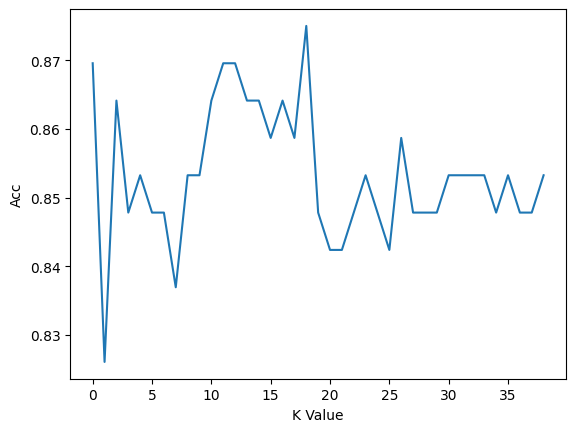

In [45]:
plt.plot(score)
plt.xlabel("K Value")
plt.ylabel("Acc")
plt.show()

In [46]:
knn=KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train,Y_train)
y_pred=knn.predict(X_test)
accuracy_score(Y_test,y_pred)

0.875

In [47]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,Y_train)
Y_pred4= dt.predict(X_test)
accuracy_score(Y_test,Y_pred4)

0.782608695652174

In [48]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,Y_train)
Y_pred5= rf.predict(X_test)
accuracy_score(Y_test,Y_pred5)


0.8695652173913043

In [49]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()
gbc.fit(X_train,Y_train)
Y_pred6 = gbc.predict(X_test)
accuracy_score(Y_test,Y_pred6)

0.8913043478260869

In [50]:
final_data = pd.DataFrame({'Models':['LR','SVM','KNN','DT','RF','GB'],
                          'ACC':[accuracy_score(Y_test,Y_pred1)*100,
                                accuracy_score(Y_test,Y_pred2)*100,
                                accuracy_score(Y_test,Y_pred3)*100,
                                accuracy_score(Y_test,Y_pred4)*100,
                                accuracy_score(Y_test,Y_pred5)*100,
                                accuracy_score(Y_test,Y_pred6)*100]})

In [51]:
final_data

,Models,ACC
0,LR,85.869565
1,SVM,90.760870
2,KNN,85.326087
3,DT,78.260870
4,RF,86.956522
5,GB,89.130435


In [54]:
import seaborn as sns

<BarContainer object of 6 artists>

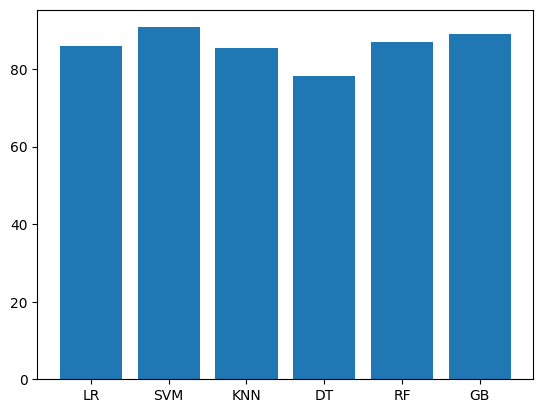

In [55]:
plt.bar(final_data['Models'],final_data['ACC'])

In [57]:
import pickle

# 1. Save the trained model (replace 'model' with your actual variable name)
with open('heart_model.pkl', 'wb') as model_file:
    pickle.dump(svm, model_file)

# 2. Save the scaler (replace 'scaler' with your actual variable name)
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(st, scaler_file)

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


#FRESH TRAINING#

In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pickle

# 1. Load Data
heart = pd.read_csv('heart.csv')

# 2. THE FIX: KEEP ONLY THE 7 FEATURES FROM YOUR WEB UI + TARGET
features_to_keep = ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']
heart = heart[features_to_keep]

# 3. Fix Missing Values
heart['trestbps'] = heart['trestbps'].fillna(heart['trestbps'].mean())
heart['chol'] = heart['chol'].fillna(heart['chol'].mean())
heart['thalch'] = heart['thalch'].fillna(heart['thalch'].mean())
heart['oldpeak'] = heart['oldpeak'].fillna(heart['oldpeak'].mean())
heart['cp'] = heart['cp'].fillna(heart['cp'].mode()[0])
heart['sex'] = heart['sex'].fillna(heart['sex'].mode()[0])

# 4. Convert Target to Binary
heart['num'] = heart['num'].apply(lambda x: 1 if x > 0 else 0)

# 5. Get Dummies
cate_val = ['sex', 'cp']
cont_val = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak'] 
heart = pd.get_dummies(heart, columns=cate_val, drop_first=True)

# 6. Scale Continuous Features
st = StandardScaler()
heart[cont_val] = st.fit_transform(heart[cont_val])

# 7. Train/Test Split
X = heart.drop('num', axis=1)
Y = heart['num']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 8. Train UI-Optimized Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, Y_train)

print("UI-Optimized Model Accuracy:", accuracy_score(Y_test, log_reg.predict(X_test)))

# 9. Save Models
with open('models/heart_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(st, f)
    
print("✅ 9-Feature UI-Optimized Model saved successfully!")

UI-Optimized Model Accuracy: 0.7771739130434783
✅ 9-Feature UI-Optimized Model saved successfully!
